In [3]:
import numpy as np
import json

# Read the JSON file
with open('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_comparison_metrics_real_inv_real.json', 'r') as f:
    data = json.load(f)

# Keep track of image names in order
image_names = list(data['results'].keys())

# Extract metrics in order: psnr, ssim, nmi, lpips, aesthetic_delta, artifact_delta
metrics = []
for image_data in data['results'].values():
    metrics.append([
        image_data['psnr'],
        image_data['ssim'],
        image_data['nmi'],
        image_data['lpips'],
        image_data['aesthetic_delta'],
        image_data['artifact_delta']
    ])

# Convert to numpy array
metrics = np.array(metrics)

# Original code
transpose = metrics.T
tenth_perc = np.percentile(transpose, 10, axis=1)
ninety_perc = np.percentile(transpose, 90, axis=1)
transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
metrics = transpose.T
final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3

# Create a dictionary of image names and their scores
results = dict(zip(image_names, final_metrics))

# Sort by score
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

# Print all results
print("\nAll images sorted by score (highest to lowest):")
print("\nImage Name | Score")
print("-" * 50)
for image_name, score in sorted_results:
    print(f"{image_name}: {score:.4f}")


All images sorted by score (highest to lowest):

Image Name | Score
--------------------------------------------------
people_standing_outside_a_building_with_clocks_bui_d488e28834.png: 0.2896
A_silver_motorcycle_parked_next_to_a_forest_filled_2a091e8f76.png: 0.2532
A_large_giraffe_is_standing_in_the_wilderness__1a86337573.png: 0.2440
Passengers_gather_to_board_oncoming_black_and_red__a2077f84db.png: 0.2213
A_picture_of_a_shaded_walk_way_and_benches___62dfd9c754.png: 0.2053
A_flock_of_white_birds_flying_over_small_boats__94d89506f7.png: 0.1968
A_large_filled_with_lots_of_purple_flowers_behind__d0483c072b.png: 0.1645
A_large_building_on_the_corner_of_the_intersection_f846a54271.png: 0.1645
Benches_surround_a_pond_in_a_park_in_autumn__6f84d617f7.png: 0.1466
A_building_tower_has_two_clocks_on_it___c038544911.png: 0.1406
a_group_of_sheep_are_all_outside_in_the_soil_toget_7b25f76c58.png: 0.1391
Ducks_are_gathered_on_rocks_beside_a_body_of_water_6cf68a1d3d.png: 0.1379
A_group_of_people_stan


Summary Statistics:
Mean: -0.4619
Median: -0.4714
Standard Deviation: 0.1993
Number of images: 6992


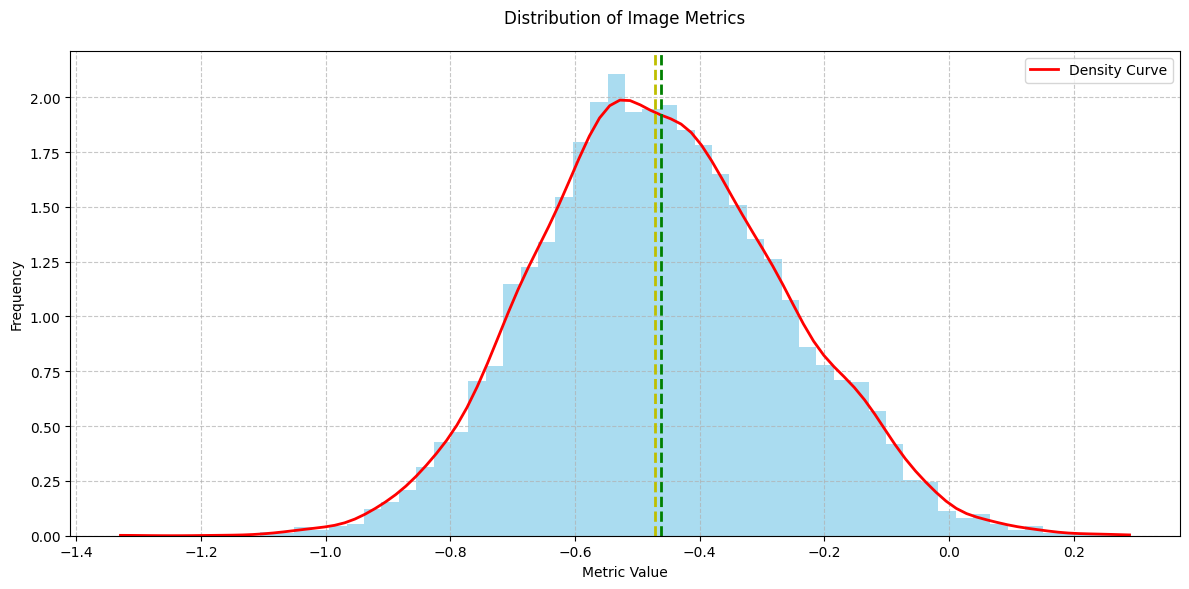

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats
# Read the JSON file
with open('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_comparison_metrics_real_inv_real.json', 'r') as f:
    data = json.load(f)



# Extract metrics in order: psnr, ssim, nmi, lpips, aesthetic_delta, artifact_delta
metrics = []
for image_data in data['results'].values():
    metrics.append([
        image_data['psnr'],
        image_data['ssim'],
        image_data['nmi'],
        image_data['lpips'],
        image_data['aesthetic_delta'],
        image_data['artifact_delta']
    ])

# Convert to numpy array
metrics = np.array(metrics)

# Original code
transpose = metrics.T
tenth_perc = np.percentile(transpose, 10, axis=1)
ninety_perc = np.percentile(transpose, 90, axis=1)
transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
metrics = transpose.T
final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3

# Create the plot
plt.figure(figsize=(12, 6))

# Create histogram
n, bins, patches = plt.hist(final_metrics, bins='auto', density=True, alpha=0.7, color='skyblue')

# Add a kernel density estimate (smooth curve)
kde = stats.gaussian_kde(final_metrics)
x_range = np.linspace(min(final_metrics), max(final_metrics), 100)
plt.plot(x_range, kde(x_range), 'r-', lw=2, label='Density Curve')

plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Distribution of Image Metrics', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add summary statistics
plt.axvline(np.mean(final_metrics), color='g', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(np.median(final_metrics), color='y', linestyle='dashed', linewidth=2, label='Median')

# Print statistics
print(f"\nSummary Statistics:")
print(f"Mean: {np.mean(final_metrics):.4f}")
print(f"Median: {np.median(final_metrics):.4f}")
print(f"Standard Deviation: {np.std(final_metrics):.4f}")
print(f"Number of images: {len(final_metrics)}")

plt.tight_layout()
plt.show()

# SD2 conditioned one


Original Statistics:
Mean: 1.0849
Median: 1.1382
Standard Deviation: 1.1684
Number of images: 7000

Real-to-Inv Statistics:
Mean: -0.6448
Median: -0.6689
Standard Deviation: 0.3142
Number of images: 7000


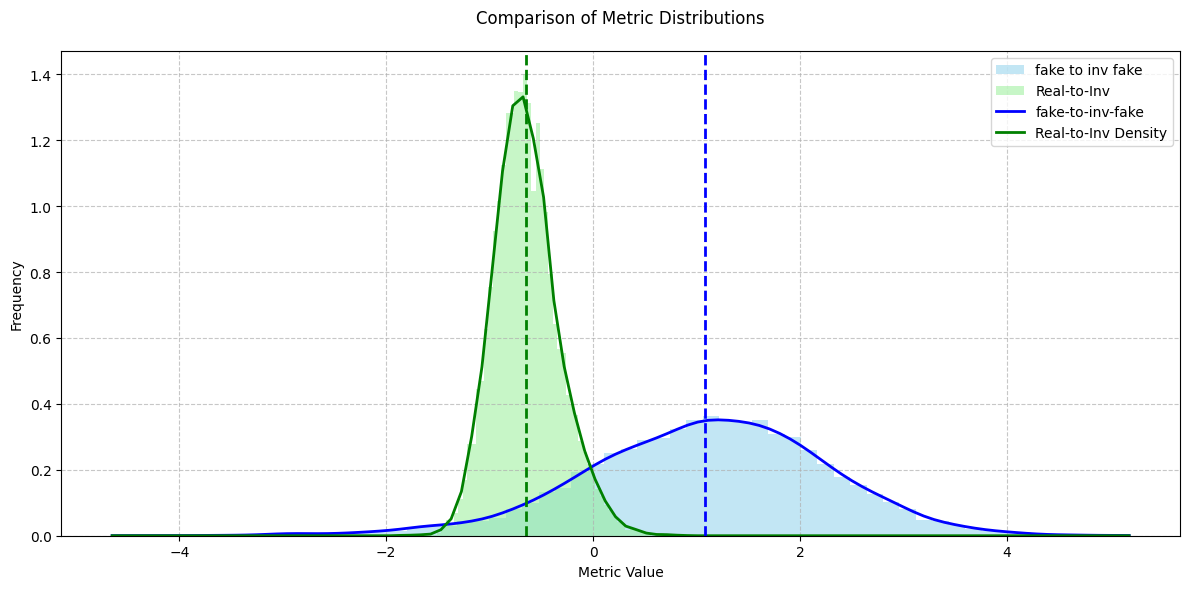

In [10]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract metrics
    metrics = []
    for image_data in data['results'].values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_conditioned_comparison_metrics_fake_inv_fake.json')  # First file
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_conditioned_comparison_metrics_real_inv_real.json')  # Second file

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='fake to inv fake')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='fake-to-inv-fake')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Original Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nOriginal Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()

# SD2 unconditioned one


Fake-to-Inv Statistics:
Mean: -2.4084
Median: -2.5686
Standard Deviation: 1.6231
Number of images: 6992

Real-to-Inv Statistics:
Mean: -0.4619
Median: -0.4714
Standard Deviation: 0.1993
Number of images: 6992


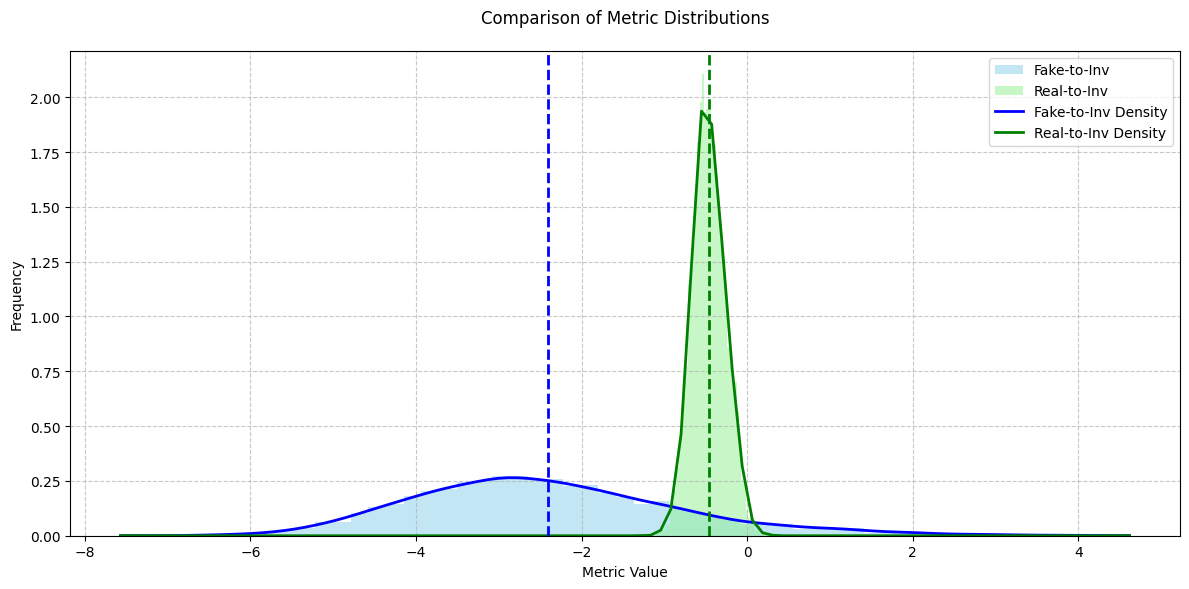

In [4]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Handle both JSON structures
    if 'results' in data:
        metrics_data = data['results']
    else:
        metrics_data = data

    # Extract metrics
    metrics = []
    for image_data in metrics_data.values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_unconditioned_comparison_metrics_fake_inv_fake.json')
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd2_comparison_metrics_real_inv_real.json')

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='Fake-to-Inv')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='Fake-to-Inv Density')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Fake-to-Inv Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nFake-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()

# SD3 condtioned one 



Original Statistics:
Mean: -0.0783
Median: -0.0790
Standard Deviation: 0.3006
Number of images: 7000

Real-to-Inv Statistics:
Mean: 0.2832
Median: 0.2776
Standard Deviation: 0.4198
Number of images: 4504


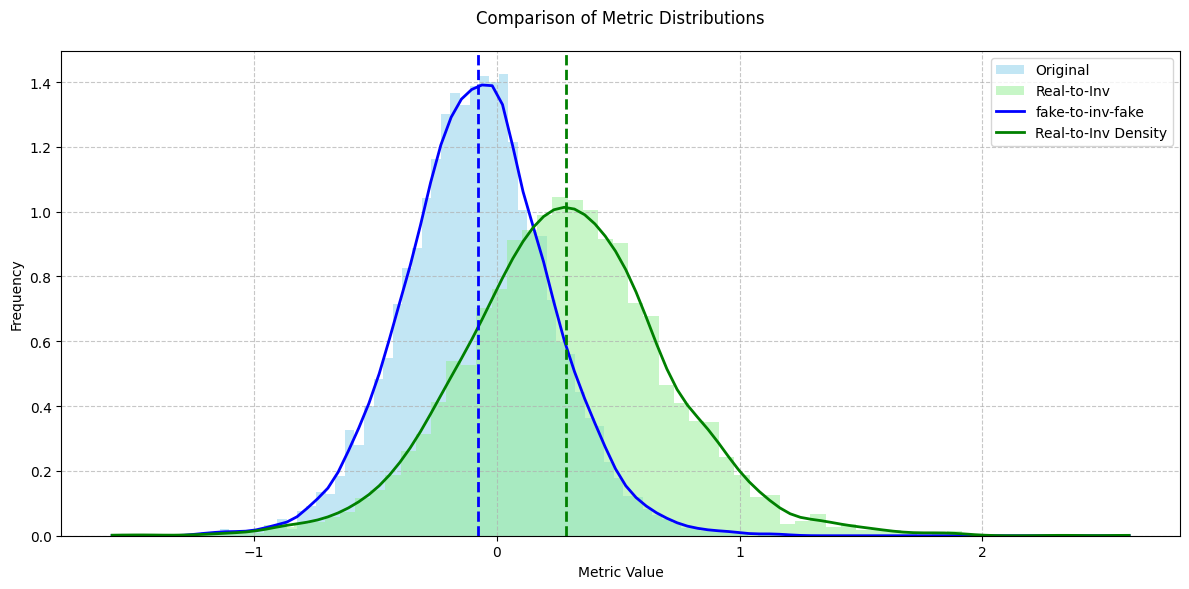

In [5]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract metrics
    metrics = []
    for image_data in data['results'].values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3_conditioned_comparison_metrics_fake_inv_fake.json')  # First file
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3_conditioned_comparison_metrics_real_inv_real.json')  # Second file

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='Original')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='fake-to-inv-fake')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Original Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nOriginal Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()

# SD3 unconditioned one


Original Statistics:
Mean: 0.2769
Median: 0.3292
Standard Deviation: 0.3357
Number of images: 7000

Real-to-Inv Statistics:
Mean: -0.8358
Median: -0.8788
Standard Deviation: 0.5374
Number of images: 7000


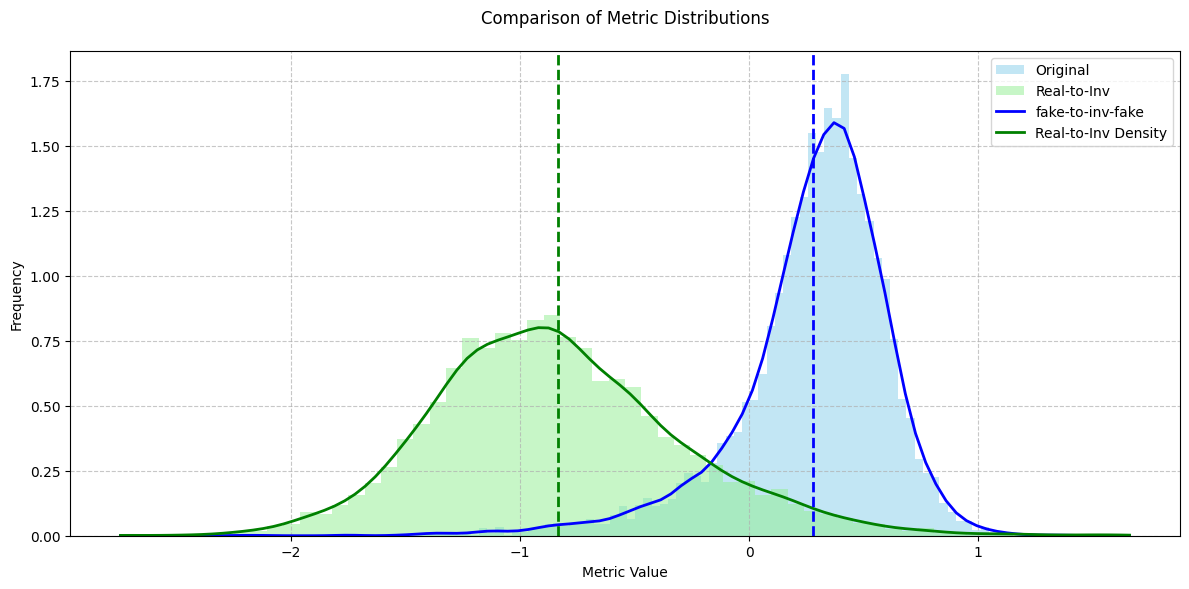

In [6]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract metrics
    metrics = []
    for image_data in data['results'].values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3_unconditioned_comparison_metrics_fake_inv_fake.json')  # First file
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3_unconditioned_comparison_metrics_real_inv_real.json')  # Second file

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='Original')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='fake-to-inv-fake')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Original Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nOriginal Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()

## Conditioned SD3.5


Original Statistics:
Mean: 0.1393
Median: 0.1758
Standard Deviation: 0.3131
Number of images: 1279

Real-to-Inv Statistics:
Mean: 0.1504
Median: 0.1555
Standard Deviation: 0.3316
Number of images: 784


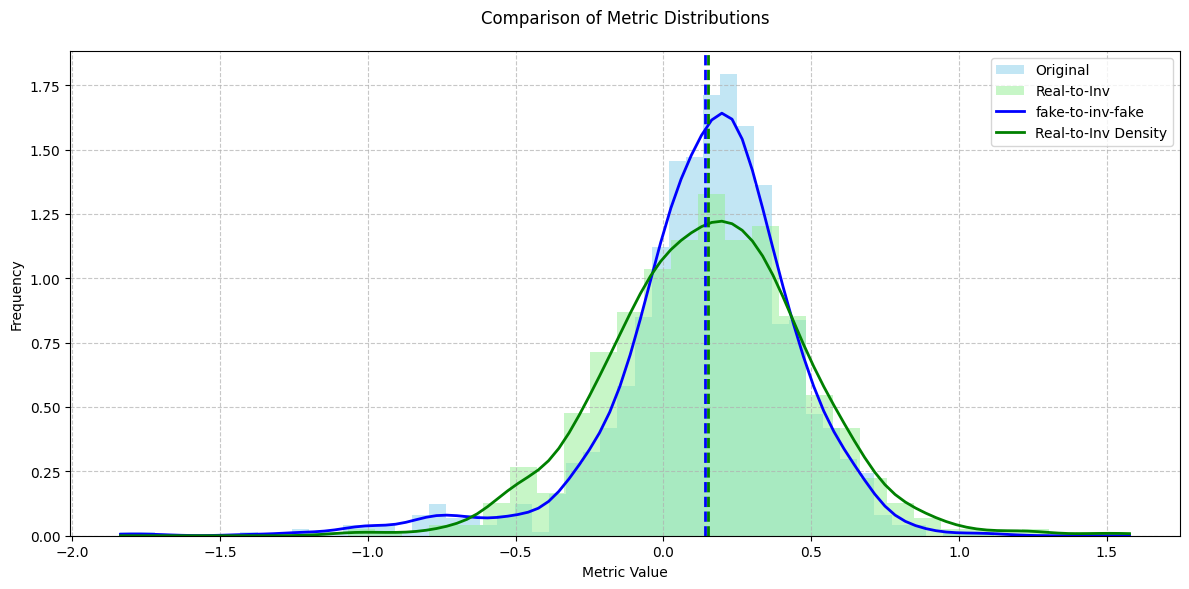

In [7]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract metrics
    metrics = []
    for image_data in data['results'].values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3.5_conditioned_comparison_metrics_fake_inv_fake.json')  # First file
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3.5_conditioned_comparison_metrics_real_inv_real.json')  # Second file

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='Original')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='fake-to-inv-fake')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Original Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nOriginal Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()

## unconditioned SD3.5


Original Statistics:
Mean: 0.3786
Median: 0.4218
Standard Deviation: 0.4250
Number of images: 1279

Real-to-Inv Statistics:
Mean: -2.9103
Median: -3.0806
Standard Deviation: 2.0652
Number of images: 1271


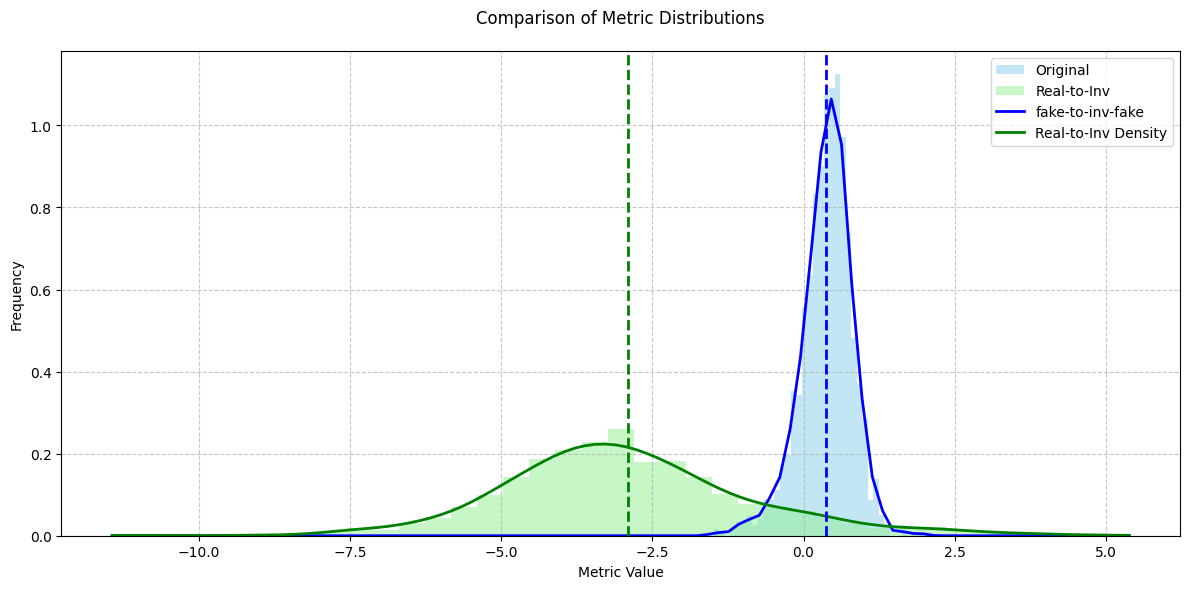

In [8]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

def process_metrics(file_path):
    # Read the JSON file
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract metrics
    metrics = []
    for image_data in data['results'].values():
        metrics.append([
            image_data['psnr'],
            image_data['ssim'],
            image_data['nmi'],
            image_data['lpips'],
            image_data['aesthetic_delta'],
            image_data['artifact_delta']
        ])

    # Convert to numpy array and process
    metrics = np.array(metrics)
    transpose = metrics.T
    tenth_perc = np.percentile(transpose, 10, axis=1)
    ninety_perc = np.percentile(transpose, 90, axis=1)
    transpose = (transpose - tenth_perc[:, np.newaxis]) / (ninety_perc[:, np.newaxis])
    metrics = transpose.T
    final_metrics = (-np.mean(metrics[:, 0:3], axis=1) + metrics[:, 3] + (metrics[:, 4] - metrics[:, 5])/2) / 3
    
    return final_metrics

# Process both files
metrics1 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3.5_unconditioned_comparison_metrics_fake_inv_fake.json')  # First file
metrics2 = process_metrics('/ephemeral/shashmi/rf-inversion-sd3/evaluation/sd3.5_unconditioned_comparison_metrics_real_inv_real.json')  # Second file

# Create the plot
plt.figure(figsize=(12, 6))

# Create histograms
plt.hist(metrics1, bins='auto', density=True, alpha=0.5, color='skyblue', label='Original')
plt.hist(metrics2, bins='auto', density=True, alpha=0.5, color='lightgreen', label='Real-to-Inv')

# Add kernel density estimates
kde1 = stats.gaussian_kde(metrics1)
kde2 = stats.gaussian_kde(metrics2)
x_range = np.linspace(min(min(metrics1), min(metrics2)), max(max(metrics1), max(metrics2)), 100)
plt.plot(x_range, kde1(x_range), 'b-', lw=2, label='fake-to-inv-fake')
plt.plot(x_range, kde2(x_range), 'g-', lw=2, label='Real-to-Inv Density')

# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Comparison of Metric Distributions', fontsize=12, pad=20)
plt.xlabel('Metric Value', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.legend()

# Add mean lines
plt.axvline(np.mean(metrics1), color='blue', linestyle='dashed', linewidth=2, label='Original Mean')
plt.axvline(np.mean(metrics2), color='green', linestyle='dashed', linewidth=2, label='Real-to-Inv Mean')

# Print statistics
print("\nOriginal Statistics:")
print(f"Mean: {np.mean(metrics1):.4f}")
print(f"Median: {np.median(metrics1):.4f}")
print(f"Standard Deviation: {np.std(metrics1):.4f}")
print(f"Number of images: {len(metrics1)}")

print("\nReal-to-Inv Statistics:")
print(f"Mean: {np.mean(metrics2):.4f}")
print(f"Median: {np.median(metrics2):.4f}")
print(f"Standard Deviation: {np.std(metrics2):.4f}")
print(f"Number of images: {len(metrics2)}")

plt.tight_layout()
plt.show()